In [1]:
# library
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import glob
import seaborn as sns

In [12]:
import pandas as pd

df_person = pd.read_csv('dataset_postur_people.csv')
df_postur = pd.read_csv('dataset_postur_more.csv')

df_main = pd.concat([df_postur, df_person], ignore_index=True)  
df_main.to_csv('dataset_postur_more.csv', index=False)  


In [18]:
# shape
print(df_main.shape)

# cek proporsi data
df_main['class'].value_counts()

(12694, 133)


class
Back       4579
Normal     4095
Forward    4020
Name: count, dtype: int64

C:\Users\jason\AppData\Local\Temp\ipykernel_20028\3106249026.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_main, x='class', y='z11', ax=ax1, palette='pastel')
C:\Users\jason\AppData\Local\Temp\ipykernel_20028\3106249026.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_main, x='class', y='z12', ax=ax2, palette='pastel')


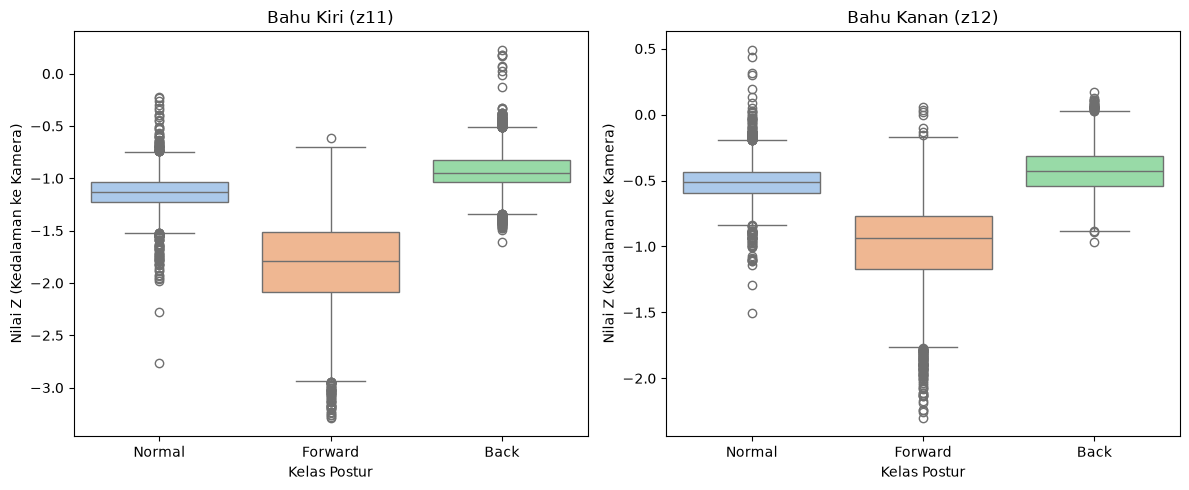

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_main, x='class', y='z11', ax=ax1, palette='pastel')
ax1.set_title('Bahu Kiri (z11)')
ax1.set_ylabel('Nilai Z (Kedalaman ke Kamera)')
ax1.set_xlabel('Kelas Postur')

# 3. Subplot Kanan: Bahu Kanan (z12)
sns.boxplot(data=df_main, x='class', y='z12', ax=ax2, palette='pastel')
ax2.set_title('Bahu Kanan (z12)')
ax2.set_ylabel('Nilai Z (Kedalaman ke Kamera)')
ax2.set_xlabel('Kelas Postur')

# Merapikan jarak antar grafik agar tidak berdempetan
plt.tight_layout()
plt.show()

C:\Users\jason\AppData\Local\Temp\ipykernel_20028\643948600.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_main, x='class', y='y2', ax=ax1, palette='pastel')
C:\Users\jason\AppData\Local\Temp\ipykernel_20028\643948600.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_main, x='class', y='y5', ax=ax2, palette='pastel')


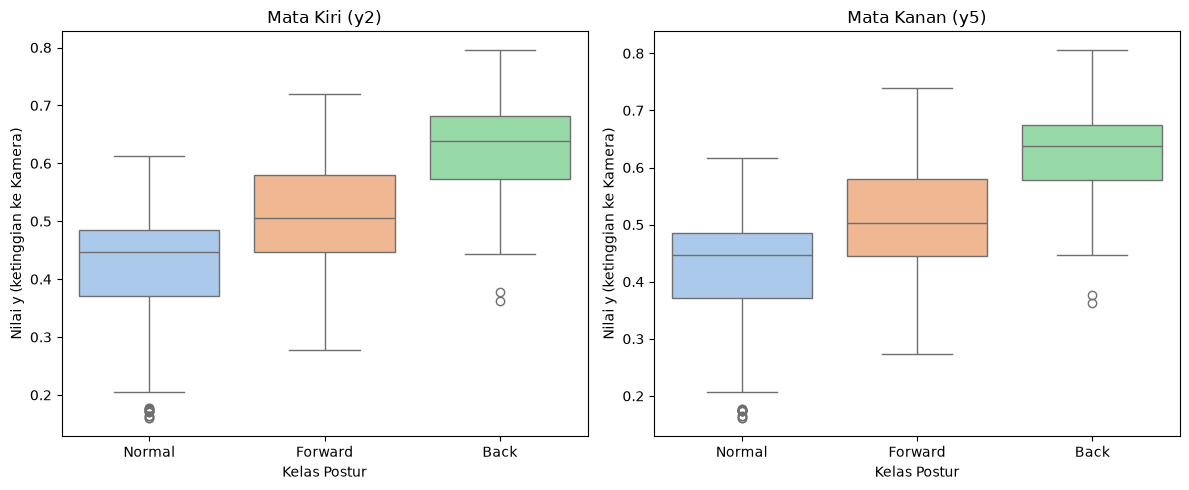

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# subplot kanan: Mata Kiri(y2)
sns.boxplot(data=df_main, x='class', y='y2', ax=ax1, palette='pastel')
ax1.set_title('Mata Kiri (y2)')
ax1.set_ylabel('Nilai y (ketinggian ke Kamera)')
ax1.set_xlabel('Kelas Postur')

# 3. Subplot Kanan: Mata Kanan (y5)
sns.boxplot(data=df_main, x='class', y='y5', ax=ax2, palette='pastel')
ax2.set_title('Mata Kanan (y5)')
ax2.set_ylabel('Nilai y (ketinggian ke Kamera)')
ax2.set_xlabel('Kelas Postur')

# Merapikan jarak antar grafik agar tidak berdempetan
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd

print("Memuat dataset original...")
df = pd.read_csv('dataset_postur_v2.csv')

def remove_outliers_per_class(dataframe, columns):
    df_final = pd.DataFrame()
    
    # Pisahkan pembersihan untuk setiap kelas postur
    for posture in dataframe['class'].unique():
        df_class = dataframe[dataframe['class'] == posture].copy()
        
        for col in columns:
            Q1 = df_class[col].quantile(0.25)
            Q3 = df_class[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Filter hanya data yang wajar di kelas tersebut
            df_class = df_class[(df_class[col] >= lower_bound) & (df_class[col] <= upper_bound)]
            
        # Gabungkan kembali data yang sudah bersih
        df_final = pd.concat([df_final, df_class])
        
    return df_final

target_columns = ['y3', 'z3', 'y6', 'z6', 'y12', 'z12', 'y13', 'z13']

df_super_clean = remove_outliers_per_class(df, target_columns)

print(f"Data awal: {len(df)} baris.")
print(f"Data bersih: {len(df_super_clean)} baris.")

df_super_clean.to_csv('dataset_postur_v2_clean.csv', index=False)
print("Save as 'dataset_postur_clean.csv'")

Memuat dataset original...
Data awal: 13178 baris.
Data bersih: 11992 baris.
Save as 'dataset_postur_clean.csv'


In [9]:
# load the cleaned data

df_clean = pd.read_csv('dataset_postur_v2_clean.csv')
df_clean['class'].value_counts()

class
Forward    4144
Back       3976
Normal     3872
Name: count, dtype: int64

C:\Users\jason\AppData\Local\Temp\ipykernel_20028\2033277745.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='class', y='y2', ax=ax1, palette='pastel')
C:\Users\jason\AppData\Local\Temp\ipykernel_20028\2033277745.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='class', y='y5', ax=ax2, palette='pastel')


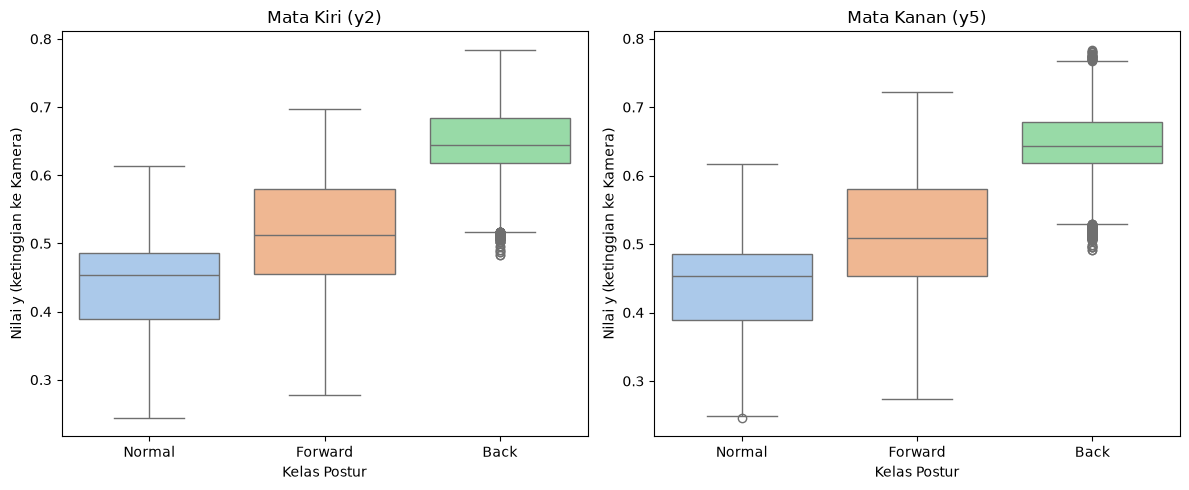

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# subplot kanan: Mata Kiri(y2)
sns.boxplot(data=df_clean, x='class', y='y2', ax=ax1, palette='pastel')
ax1.set_title('Mata Kiri (y2)')
ax1.set_ylabel('Nilai y (ketinggian ke Kamera)')
ax1.set_xlabel('Kelas Postur')

# 3. Subplot Kanan: Mata Kanan (y5)
sns.boxplot(data=df_clean, x='class', y='y5', ax=ax2, palette='pastel')
ax2.set_title('Mata Kanan (y5)')
ax2.set_ylabel('Nilai y (ketinggian ke Kamera)')
ax2.set_xlabel('Kelas Postur')

# Merapikan jarak antar grafik agar tidak berdempetan
plt.tight_layout()
plt.show()

C:\Users\jason\AppData\Local\Temp\ipykernel_20028\3519605707.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='class', y='z11', ax=ax1, palette='pastel')
C:\Users\jason\AppData\Local\Temp\ipykernel_20028\3519605707.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='class', y='z12', ax=ax2, palette='pastel')


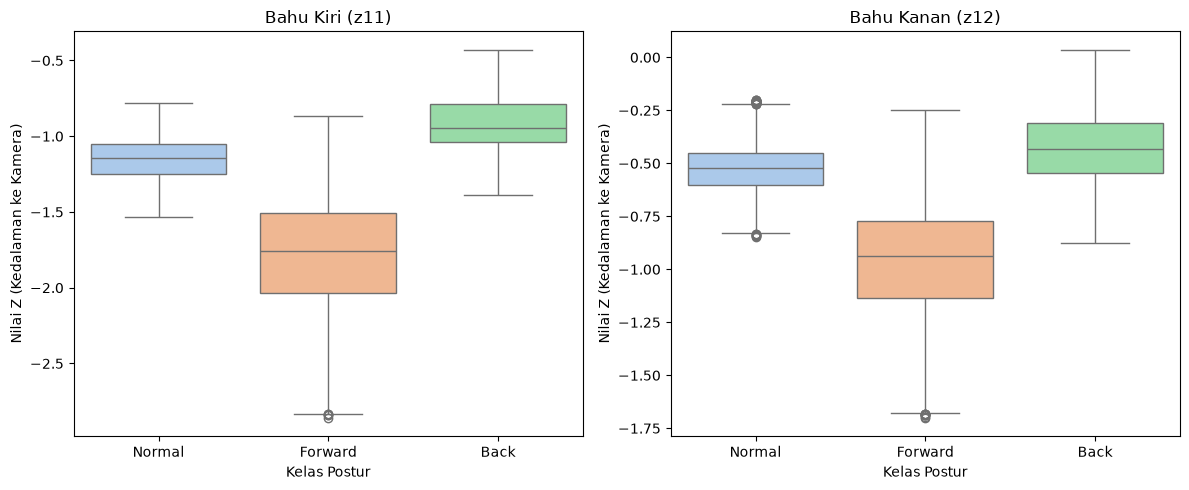

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_clean, x='class', y='z11', ax=ax1, palette='pastel')
ax1.set_title('Bahu Kiri (z11)')
ax1.set_ylabel('Nilai Z (Kedalaman ke Kamera)')
ax1.set_xlabel('Kelas Postur')

# 3. Subplot Kanan: Bahu Kanan (z12)
sns.boxplot(data=df_clean, x='class', y='z12', ax=ax2, palette='pastel')
ax2.set_title('Bahu Kanan (z12)')
ax2.set_ylabel('Nilai Z (Kedalaman ke Kamera)')
ax2.set_xlabel('Kelas Postur')

# Merapikan jarak antar grafik agar tidak berdempetan
plt.tight_layout()
plt.show()